### Imports and Setup

Importing all necessary libraries, defines the FocalLoss class, sets up the device, and includes a utility function for monitoring memory usage. The FocalLoss gamma is set to 4.0 to focus on hard-to-classify examples, aiding sensitivity.

In [6]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import torchvision.transforms as transforms
from efficientnet_pytorch import EfficientNet
from torchvision.models import mobilenet_v3_large  # Upgraded to MobileNetV3-Large
from imblearn.over_sampling import RandomOverSampler
import psutil
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define Focal Loss for classification
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 4.0, reduction: str = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Function to monitor memory usage
def print_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    print(f"CPU Memory Usage: {mem_info.rss / 1024 / 1024:.2f} MiB")
    if torch.cuda.is_available():
        print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024 / 1024:.2f} MiB")
        print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1024 / 1024:.2f} MiB")

C:\Users\bestg\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Using device: cuda


In [3]:
# Define paths based on the folder structure
DATA_DIR = r"C:\Users\bestg\Downloads\Major Project\MAG_KD2\Dataset\HAM10000"  # Raw string for Windows paths
IMAGE_DIRS = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2")
]
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
SEG_DIR = os.path.join(DATA_DIR, "HAM10000_segmentations")

In [4]:
# Load metadata and map labels
def load_metadata(metadata_path: str) -> pd.DataFrame:
    df = pd.read_csv(metadata_path)
    df['label'] = df['dx'].map({
        'nv': 0, 'bcc': 1, 'bkl': 0, 'df': 0, 'vasc': 0,  # Benign
        'mel': 1, 'akiec': 1  # Malignant
    })
    return df

### Data Preparation

Explanation: This cell defines the dataset class, applies data augmentation, and prepares the HAM10000 dataset with 1:1 oversampling to balance benign and malignant classes. The dataset is split into training, validation, and test sets, and DataLoaders are created for batch processing.

In [6]:
# Custom Dataset class for HAM10000
class HAM10000Dataset(Dataset):
    def __init__(self, image_paths: list, labels: list, seg_paths: list, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.seg_paths = seg_paths
        self.transform = transform

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> tuple:
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        seg_path = self.seg_paths[idx]
        seg_mask = Image.open(seg_path).convert('L')
        seg_mask = np.array(seg_mask, dtype=np.uint8)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform:
            augmented = self.transform(image=image, mask=seg_mask)
            image = augmented['image']
            seg_mask = augmented['mask']

        image = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0
        image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)
        
        seg_mask = torch.from_numpy(seg_mask).float() / 255.0
        seg_mask = (seg_mask > 0.5).float()
        seg_mask = seg_mask.unsqueeze(0)

        return image, label, seg_mask

In [7]:
# Data augmentation for diversity
def get_augmentation() -> A.Compose:
    return A.Compose([
        A.RandomBrightnessContrast(p=0.5, brightness_limit=0.2, contrast_limit=0.2),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=25, p=0.5),
        A.Resize(224, 224)
    ], additional_targets={'mask': 'mask'})

In [8]:
# Prepare dataset with 1:1 oversampling
def prepare_ham10000_dataset(data_dir: str, metadata_path: str, seg_dir: str):
    metadata = load_metadata(metadata_path)

    image_paths = []
    seg_paths = []
    labels = []
    for img_dir in IMAGE_DIRS:
        for img_name in os.listdir(img_dir):
            if img_name.endswith('.jpg'):
                img_id = img_name.split('.')[0]
                img_path = os.path.join(img_dir, img_name)
                seg_path = os.path.join(seg_dir, f"{img_id}_segmentation.png")
                if os.path.exists(seg_path):
                    label = metadata[metadata['image_id'] == img_id]['label'].iloc[0]
                    image_paths.append(img_path)
                    seg_paths.append(seg_path)
                    labels.append(label)
                    
    # Print class distribution before oversampling
    print("Class distribution before oversampling:")
    unique, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique, counts):
        class_name = "Benign" if label == 0 else "Malignant"
        print(f"{class_name}: {count} ({(count / len(labels) * 100):.2f}%)")  
        
    train_paths, temp_paths, train_labels, temp_labels, train_seg_paths, temp_seg_paths = train_test_split(
        image_paths, labels, seg_paths, test_size=0.2, stratify=labels, random_state=42
    )
    val_paths, test_paths, val_labels, test_labels, val_seg_paths, test_seg_paths = train_test_split(
        temp_paths, temp_labels, temp_seg_paths, test_size=0.5, stratify=temp_labels, random_state=42
    )

    # Partial oversampling to achieve 1.5:1 ratio (benign:malignant)
    ros = RandomOverSampler(sampling_strategy=0.67, random_state=42)
    train_indices = np.arange(len(train_paths)).reshape(-1, 1)
    train_labels_array = np.array(train_labels).reshape(-1, 1)
    train_indices_resampled, _ = ros.fit_resample(train_indices, train_labels_array)
    train_indices_resampled = train_indices_resampled.flatten()

    train_paths_resampled = [train_paths[i] for i in train_indices_resampled]
    train_labels_resampled = [train_labels[i] for i in train_indices_resampled]
    train_seg_paths_resampled = [train_seg_paths[i] for i in train_indices_resampled]

    print("Training set class distribution after oversampling:")
    print(pd.Series(train_labels_resampled).value_counts())

    # Print class distribution after oversampling
    print("Class distribution after oversampling:")
    unique, counts = np.unique(train_labels_resampled, return_counts=True)
    for label, count in zip(unique, counts):
        class_name = "Benign" if label == 0 else "Malignant"
        print(f"{class_name}: {count} ({(count / len(train_labels_resampled) * 100):.2f}%)")

    train_transform = get_augmentation()
    val_test_transform = A.Compose([
        A.Resize(224, 224)
    ], additional_targets={'mask': 'mask'})

    train_dataset = HAM10000Dataset(train_paths_resampled, train_labels_resampled, train_seg_paths_resampled, transform=train_transform)
    val_dataset = HAM10000Dataset(val_paths, val_labels, val_seg_paths, transform=val_test_transform)
    test_dataset = HAM10000Dataset(test_paths, test_labels, test_seg_paths, transform=val_test_transform)

    # Display sample images
    sample_idx = 0
    sample_image, sample_label, sample_mask = train_dataset[sample_idx]
    sample_image = sample_image.numpy().transpose((1, 2, 0))  # Convert to HWC for display
    sample_image = np.clip(sample_image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)  # Undo normalization
    sample_mask = sample_mask.squeeze(0).numpy()  # Remove channel dimension

    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_image)
    plt.title(f"Augmented Image (Label: {'Malignant' if sample_label.item() == 1 else 'Benign'})")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(sample_mask, cmap='gray')
    plt.title("Segmentation Mask")
    plt.axis('off')
    plt.show()    

    return train_dataset, val_dataset, test_dataset

Class distribution before oversampling:
Benign: 8061 (80.49%)
Malignant: 1954 (19.51%)
Training set class distribution after oversampling:
0    6449
1    4320
Name: count, dtype: int64
Class distribution after oversampling:
Benign: 6449 (59.88%)
Malignant: 4320 (40.12%)


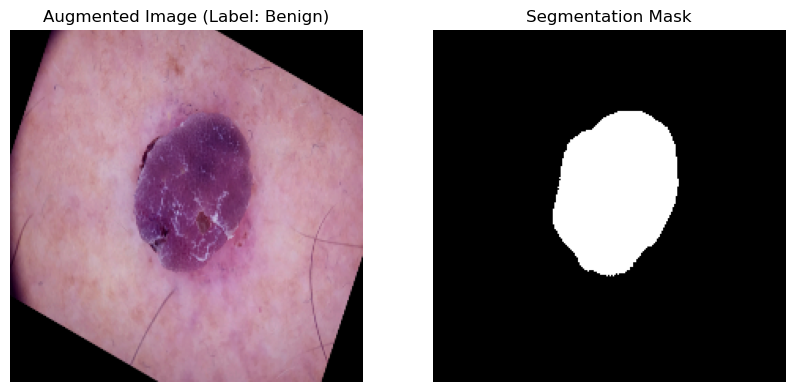

Training set size: 10769
Validation set size: 1001
Test set size: 1002


In [9]:
# Prepare datasets
train_dataset, val_dataset, test_dataset = prepare_ham10000_dataset(DATA_DIR, METADATA_PATH, SEG_DIR)

# Create DataLoaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

### Hyperparameter Tuning of Teacher Model

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import itertools
import psutil
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
from efficientnet_pytorch import EfficientNet

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
np.random.seed(42)

# Define Focal Loss for classification
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 4.0, reduction: str = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Define Teacher Model (EfficientNet-B4 with Segmentation Head)
class TeacherModel(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super(TeacherModel, self).__init__()
        self.backbone = EfficientNet.from_pretrained('efficientnet-b4')
        self.backbone._fc = nn.Linear(self.backbone._fc.in_features, 2)
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(self.backbone._conv_head.out_channels, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.ConvTranspose2d(256, 1, kernel_size=4, stride=2, padding=1)
            # No Sigmoid to match BCEWithLogitsLoss
        )

    def forward(self, x):
        features = self.backbone.extract_features(x)
        class_logits = self.backbone._avg_pooling(features)
        class_logits = class_logits.flatten(1)
        class_logits = self.backbone._dropout(class_logits)
        class_logits = self.backbone._fc(class_logits)
        seg_maps = self.segmentation_head(features)
        return class_logits, seg_maps

# Function to monitor memory usage
def print_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    print(f"CPU Memory Usage: {mem_info.rss / 1024 / 1024:.2f} MiB")
    if torch.cuda.is_available():
        print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024 / 1024:.2f} MiB")
        print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1024 / 1024:.2f} MiB")

Using device: cuda


### Define Hyperparameter Grid

Explanation: This cell defines the hyperparameter grid to search over, including learning rates (initial and fine-tuning), class weights, batch sizes, and dropout rates.

In [13]:
# Define hyperparameter grid
param_grid = {
    'lr_initial': [0.0001, 0.0005],  # Reduced to 2 values
    'lr_finetune': [0.00001, 0.00005],
    'class_weights': [
        [1.0, 3.0],  # Less bias toward malignant
        [1.0, 4.0]   # Current
    ],
    'batch_size': [4, 8],  # Reduced to 2 values
    'dropout_rate': [0.3, 0.5]
}

# Generate all combinations
param_combinations = list(itertools.product(
    param_grid['lr_initial'],
    param_grid['lr_finetune'],
    param_grid['class_weights'],
    param_grid['batch_size'],
    param_grid['dropout_rate']
))

# Shuffle combinations to ensure random sampling
np.random.seed(42)  # For reproducibility
np.random.shuffle(param_combinations)

print(f"Total hyperparameter combinations available: {len(param_combinations)}")
print(f"Will limit to a maximum of 16 iterations.")

Total hyperparameter combinations available: 32
Will limit to a maximum of 16 iterations.


### Training and Evaluation Function

Explanation: This cell defines a function to train the teacher model for a few epochs (initial training and fine-tuning phases) and evaluate it on the validation set. It returns the average validation metrics (accuracy, sensitivity, specificity) at a given threshold (0.5).

In [15]:
def train_and_evaluate_teacher(model, train_loader, val_loader, params, num_epochs_initial=5, num_epochs_finetune=3, device=device):
    lr_initial, lr_finetune, class_weights, batch_size, dropout_rate = params
    
    # Create DataLoaders with the specified batch size
    train_loader = DataLoader(train_loader.dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_loader.dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model and optimizer
    model = TeacherModel(dropout_rate=dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr_initial, weight_decay=5e-4) 
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion_class = FocalLoss(alpha=class_weights_tensor, gamma=4.0)
    criterion_seg = nn.BCEWithLogitsLoss()
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)
    scaler = GradScaler()
    accumulation_steps = 4

    # Initial training phase
    for epoch in range(num_epochs_initial):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        for i, (images, labels, seg_masks) in enumerate(train_loader):
            images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
            
            with autocast():
                class_logits, seg_maps = model(images)
                class_loss = criterion_class(class_logits, labels)
                seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                loss = class_loss + 0.3 * seg_loss
            
            scaler.scale(loss / accumulation_steps).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            train_loss += loss.item() * accumulation_steps
        
        if (i + 1) % accumulation_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        avg_train_loss = train_loss / len(train_loader)
        print(f"Initial Training Epoch {epoch + 1}/{num_epochs_initial}, Train Loss: {avg_train_loss:.4f}")
        scheduler.step()
        torch.cuda.empty_cache()
        print_memory_usage()

    # Fine-tuning phase
    for param in model.backbone.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=lr_finetune, weight_decay=5e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_finetune)
    
    for epoch in range(num_epochs_finetune):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        for i, (images, labels, seg_masks) in enumerate(train_loader):
            images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
            
            with autocast():
                class_logits, seg_maps = model(images)
                class_loss = criterion_class(class_logits, labels)
                seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                loss = class_loss + 0.3 * seg_loss
            
            scaler.scale(loss / accumulation_steps).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            train_loss += loss.item() * accumulation_steps
        
        if (i + 1) % accumulation_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        avg_train_loss = train_loss / len(train_loader)
        print(f"Fine-tuning Epoch {epoch + 1}/{num_epochs_finetune}, Train Loss: {avg_train_loss:.4f}")
        scheduler.step()
        torch.cuda.empty_cache()
        print_memory_usage()
    
    # Evaluation on validation set
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            class_logits, _ = model(images)
            probs = torch.softmax(class_logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Compute metrics at threshold 0.5
    threshold = 0.5
    preds = (np.array(all_probs) > threshold).astype(int)
    accuracy = np.mean(preds == all_labels)
    report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
    sensitivity = report['Malignant']['recall']
    specificity = report['Benign']['recall']
    
    return accuracy, sensitivity, specificity

### Hyperparameter Tuning Loop

Explanation: This cell runs the grid search, training the teacher model for each hyperparameter combination and evaluating on the validation set. It selects the best combination based on a weighted score (prioritizing sensitivity, then accuracy and specificity).

In [17]:
# Hyperparameter tuning loop
best_score = -float('inf')
best_params = None
results = []
max_iterations = 16
iteration_count = 0

for params in param_combinations:
    if iteration_count >= max_iterations:
        print(f"Reached maximum iterations ({max_iterations}). Stopping hyperparameter tuning.")
        break
    
    lr_initial, lr_finetune, class_weights, batch_size, dropout_rate = params
    print(f"\nTesting combination {iteration_count + 1}/{max_iterations}: lr_initial={lr_initial}, lr_finetune={lr_finetune}, class_weights={class_weights}, batch_size={batch_size}, dropout_rate={dropout_rate}")
    
    # Initialize a new teacher model for each combination
    model = TeacherModel(dropout_rate=dropout_rate)
    
    # Train and evaluate
    accuracy, sensitivity, specificity = train_and_evaluate_teacher(
        model, train_loader, val_loader, params, num_epochs_initial=5, num_epochs_finetune=3, device=device
    )
    
    # Compute a weighted score (prioritize sensitivity, then accuracy and specificity)
    score = 0.5 * sensitivity + 0.3 * accuracy + 0.2 * specificity
    results.append({
        'params': params,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'score': score
    })
    
    print(f"Validation - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, Score: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = params
    
    iteration_count += 1

# Print best parameters
if best_params is not None:
    print(f"\nBest parameters: lr_initial={best_params[0]}, lr_finetune={best_params[1]}, class_weights={best_params[2]}, batch_size={best_params[3]}, dropout_rate={best_params[4]}")
    print(f"Best score: {best_score:.4f}")
else:
    print("\nNo parameters were evaluated. Please check the hyperparameter grid.")


Testing combination 1/16: lr_initial=0.0005, lr_finetune=5e-05, class_weights=[1.0, 4.0], batch_size=4, dropout_rate=0.5
Loaded pretrained weights for efficientnet-b4
Loaded pretrained weights for efficientnet-b4


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Initial Training Epoch 1/5, Train Loss: 1.3373
CPU Memory Usage: 2015.57 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 442.00 MiB
Initial Training Epoch 2/5, Train Loss: 1.1041
CPU Memory Usage: 1823.95 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 442.00 MiB
Initial Training Epoch 3/5, Train Loss: 0.9802
CPU Memory Usage: 1824.17 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 442.00 MiB
Initial Training Epoch 4/5, Train Loss: 0.8535
CPU Memory Usage: 1824.97 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 442.00 MiB
Initial Training Epoch 5/5, Train Loss: 0.6804
CPU Memory Usage: 1824.74 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 442.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fine-tuning Epoch 1/3, Train Loss: 0.6391
CPU Memory Usage: 1825.72 MiB
GPU Memory Allocated: 341.67 MiB
GPU Memory Cached: 404.00 MiB
Fine-tuning Epoch 2/3, Train Loss: 0.5913
CPU Memory Usage: 1825.66 MiB
GPU Memory Allocated: 341.67 MiB
GPU Memory Cached: 406.00 MiB
Fine-tuning Epoch 3/3, Train Loss: 0.5547
CPU Memory Usage: 1825.72 MiB
GPU Memory Allocated: 341.67 MiB
GPU Memory Cached: 406.00 MiB
Validation - Accuracy: 0.7942, Sensitivity: 0.9077, Specificity: 0.7667, Score: 0.8455

Testing combination 2/16: lr_initial=0.0001, lr_finetune=5e-05, class_weights=[1.0, 4.0], batch_size=8, dropout_rate=0.5
Loaded pretrained weights for efficientnet-b4
Loaded pretrained weights for efficientnet-b4


...

Initial Training Epoch 1/5, Train Loss: 1.0430
CPU Memory Usage: 601.42 MiB
GPU Memory Allocated: 341.69 MiB
GPU Memory Cached: 454.00 MiB
Initial Training Epoch 2/5, Train Loss: 0.8049
CPU Memory Usage: 601.06 MiB
GPU Memory Allocated: 341.69 MiB
GPU Memory Cached: 454.00 MiB
Initial Training Epoch 3/5, Train Loss: 0.6796
CPU Memory Usage: 601.09 MiB
GPU Memory Allocated: 341.69 MiB
GPU Memory Cached: 456.00 MiB
Initial Training Epoch 4/5, Train Loss: 0.5696
CPU Memory Usage: 601.10 MiB
GPU Memory Allocated: 341.69 MiB
GPU Memory Cached: 454.00 MiB
Initial Training Epoch 5/5, Train Loss: 0.4993
CPU Memory Usage: 601.03 MiB
GPU Memory Allocated: 341.69 MiB
GPU Memory Cached: 454.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fine-tuning Epoch 1/3, Train Loss: 0.4762
CPU Memory Usage: 601.23 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 420.00 MiB
Fine-tuning Epoch 2/3, Train Loss: 0.4512
CPU Memory Usage: 601.22 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 424.00 MiB
Fine-tuning Epoch 3/3, Train Loss: 0.4349
CPU Memory Usage: 600.33 MiB
GPU Memory Allocated: 342.30 MiB
GPU Memory Cached: 422.00 MiB
Validation - Accuracy: 0.8372, Sensitivity: 0.8923, Specificity: 0.8238, Score: 0.8621

Testing combination 11/16: lr_initial=0.0001, lr_finetune=1e-05, class_weights=[1.0, 4.0], batch_size=4, dropout_rate=0.3
Loaded pretrained weights for efficientnet-b4
Loaded pretrained weights for efficientnet-b4


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\2521388725.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

In [38]:
print(best_params)
print("Testing combination 7/16: lr_initial=0.0005, lr_finetune=5e-05, class_weights=[1.0, 4.0], batch_size=8, dropout_rate=0.3")
print("Validation - Accuracy: 0.8881, Sensitivity: 0.9333, Specificity: 0.8772, Score: 0.9085")

(0.0005, 5e-05, [1.0, 4.0], 8, 0.3)
Testing combination 7/16: lr_initial=0.0005, lr_finetune=5e-05, class_weights=[1.0, 4.0], batch_size=8, dropout_rate=0.3
Validation - Accuracy: 0.8881, Sensitivity: 0.9333, Specificity: 0.8772, Score: 0.9085


### Retrain with Best Hyperparameters

Explanation: This cell retrains the teacher model using the best hyperparameters for more epochs (e.g., 25 initial + 10 fine-tuning) to ensure convergence, and tracks metrics for plotting.

In [40]:
# Extract best parameters
best_lr_initial, best_lr_finetune, best_class_weights, best_batch_size, best_dropout_rate = best_params

# Create DataLoaders with the best batch size
train_loader = DataLoader(train_loader.dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_loader.dataset, batch_size=best_batch_size, shuffle=False)

# Initialize teacher model
teacher_model = TeacherModel(dropout_rate=best_dropout_rate)

# Training function with metric tracking
def train_teacher_model(model, train_loader, val_loader, num_epochs_initial=25, num_epochs_finetune=10, device=device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=best_lr_initial, weight_decay=5e-4)
    class_weights_tensor = torch.tensor(best_class_weights, dtype=torch.float).to(device)
    criterion_class = FocalLoss(alpha=class_weights_tensor, gamma=4.0)
    criterion_seg = nn.BCEWithLogitsLoss()
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)
    scaler = GradScaler()
    accumulation_steps = 4

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_sensitivity': [],
        'val_specificity': []
    }

    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    for epoch in range(num_epochs_initial):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        for i, (images, labels, seg_masks) in enumerate(train_loader):
            images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
            
            with autocast():
                class_logits, seg_maps = model(images)
                class_loss = criterion_class(class_logits, labels)
                seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                loss = class_loss + 0.3 * seg_loss
            
            scaler.scale(loss / accumulation_steps).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            train_loss += loss.item() * accumulation_steps
        
        if (i + 1) % accumulation_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        model.eval()
        val_loss = 0.0
        all_probs, all_labels = [], []
        with torch.no_grad():
            for images, labels, seg_masks in val_loader:
                images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
                with autocast():
                    class_logits, seg_maps = model(images)
                    class_loss = criterion_class(class_logits, labels)
                    seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                    seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                    loss = class_loss + 0.3 * seg_loss
                val_loss += loss.item()
                probs = torch.softmax(class_logits, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        preds = (np.array(all_probs) > 0.5).astype(int)
        report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
        val_accuracy = np.mean(preds == all_labels)
        val_sensitivity = report['Malignant']['recall']
        val_specificity = report['Benign']['recall']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_sensitivity'].append(val_sensitivity)
        history['val_specificity'].append(val_specificity)

        print(f"Initial Training Epoch {epoch + 1}/{num_epochs_initial}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val Sensitivity: {val_sensitivity:.4f}, Val Specificity: {val_specificity:.4f}")
        
        scheduler.step()
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "teacher_model_best.pth")
            print("Saved best teacher model checkpoint")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break
        
        torch.cuda.empty_cache()
        print_memory_usage()

    # Fine-tuning phase
    print("\nStarting fine-tuning phase...")
    for param in model.backbone.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=best_lr_finetune, weight_decay=5e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_finetune)
    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(num_epochs_finetune):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        for i, (images, labels, seg_masks) in enumerate(train_loader):
            images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
            
            with autocast():
                class_logits, seg_maps = model(images)
                class_loss = criterion_class(class_logits, labels)
                seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                total_loss = class_loss + 0.3 * seg_loss
            
            scaler.scale(total_loss / accumulation_steps).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            train_loss += total_loss.item() * accumulation_steps
        
        if (i + 1) % accumulation_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        model.eval()
        val_loss = 0.0
        all_probs, all_labels = [], []
        with torch.no_grad():
            for images, labels, seg_masks in val_loader:
                images, labels, seg_masks = images.to(device), labels.to(device), seg_masks.to(device)
                with autocast():
                    class_logits, seg_maps = model(images)
                    class_loss = criterion_class(class_logits, labels)
                    seg_masks_resized = nn.functional.interpolate(seg_masks, size=(28, 28), mode='bilinear', align_corners=False)
                    seg_loss = criterion_seg(seg_maps, seg_masks_resized)
                    loss = class_loss + 0.3 * seg_loss
                val_loss += loss.item()
                probs = torch.softmax(class_logits, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        preds = (np.array(all_probs) > 0.5).astype(int)
        report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
        val_accuracy = np.mean(preds == all_labels)
        val_sensitivity = report['Malignant']['recall']
        val_specificity = report['Benign']['recall']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_sensitivity'].append(val_sensitivity)
        history['val_specificity'].append(val_specificity)

        print(f"Fine-tuning Epoch {epoch + 1}/{num_epochs_finetune}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val Sensitivity: {val_sensitivity:.4f}, Val Specificity: {val_specificity:.4f}")
        
        scheduler.step()
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "teacher_model_finetune_best.pth")
            print("Saved best teacher model checkpoint (fine-tuning)")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at fine-tuning epoch {epoch + 1}")
                break
        
        torch.cuda.empty_cache()
        print_memory_usage()
    
    torch.save(model.state_dict(), "teacher_model_final.pth")
    print("Teacher model training completed.")
    return history

# Train with best hyperparameters
teacher_history = train_teacher_model(teacher_model, train_loader, val_loader, num_epochs_initial=25, num_epochs_finetune=10, device=device)

Loaded pretrained weights for efficientnet-b4


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Initial Training Epoch 1/25, Train Loss: 1.2588, Val Loss: 0.2214, Val Accuracy: 0.6843, Val Sensitivity: 0.9538, Val Specificity: 0.6191
Saved best teacher model checkpoint
CPU Memory Usage: 220.78 MiB
GPU Memory Allocated: 779.56 MiB
GPU Memory Cached: 874.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Initial Training Epoch 2/25, Train Loss: 0.9892, Val Loss: 0.2000, Val Accuracy: 0.6464, Val Sensitivity: 0.9795, Val Specificity: 0.5658
Saved best teacher model checkpoint
CPU Memory Usage: 222.95 MiB
GPU Memory Allocated: 779.56 MiB
GPU Memory Cached: 874.00 MiB


...

Fine-tuning Epoch 4/10, Train Loss: 0.3532, Val Loss: 0.2249, Val Accuracy: 0.8851, Val Sensitivity: 0.8821, Val Specificity: 0.8859
CPU Memory Usage: 427.84 MiB
GPU Memory Allocated: 777.95 MiB
GPU Memory Cached: 860.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fine-tuning Epoch 5/10, Train Loss: 0.3306, Val Loss: 0.2131, Val Accuracy: 0.8871, Val Sensitivity: 0.8872, Val Specificity: 0.8871
CPU Memory Usage: 427.86 MiB
GPU Memory Allocated: 777.95 MiB
GPU Memory Cached: 860.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1183104641.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fine-tuning Epoch 6/10, Train Loss: 0.3048, Val Loss: 0.2124, Val Accuracy: 0.8721, Val Sensitivity: 0.8821, Val Specificity: 0.8697
Early stopping at fine-tuning epoch 6
Teacher model training completed.


### Plot Training Metrics

Explanation: This cell plots the training and validation metrics (loss, accuracy, sensitivity, specificity) over epochs to visualize the training progress.

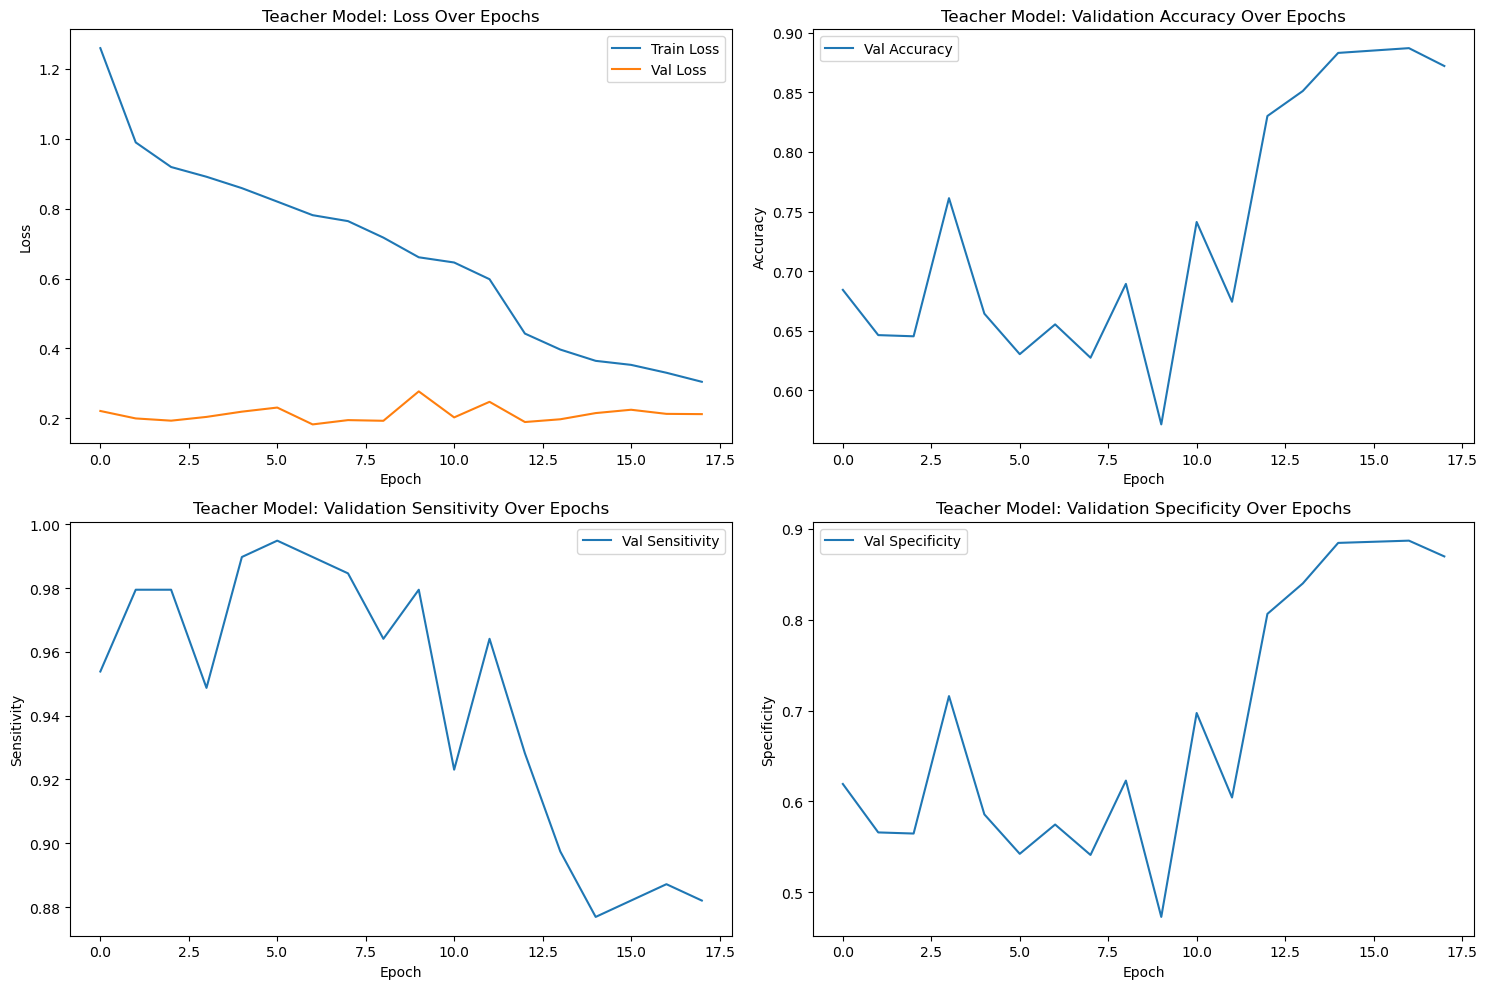

In [42]:
# Plot teacher model metrics
plt.figure(figsize=(15, 10))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(teacher_history['train_loss'], label='Train Loss')
plt.plot(teacher_history['val_loss'], label='Val Loss')
plt.title('Teacher Model: Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(2, 2, 2)
plt.plot(teacher_history['val_accuracy'], label='Val Accuracy')
plt.title('Teacher Model: Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Sensitivity
plt.subplot(2, 2, 3)
plt.plot(teacher_history['val_sensitivity'], label='Val Sensitivity')
plt.title('Teacher Model: Validation Sensitivity Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Sensitivity')
plt.legend()

# Plot Specificity
plt.subplot(2, 2, 4)
plt.plot(teacher_history['val_specificity'], label='Val Specificity')
plt.title('Teacher Model: Validation Specificity Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Specificity')
plt.legend()

plt.tight_layout()
plt.show()

### Final Evaluation on Test Set

Explanation: This cell evaluates the tuned teacher model on the test set, testing multiple thresholds to find the best operating point. It also plots the confusion matrix.

Threshold 0.4: Accuracy 0.8303, Sensitivity 0.9337, Specificity 0.8052
Threshold 0.45: Accuracy 0.8503, Sensitivity 0.8980, Specificity 0.8387
Threshold 0.5: Accuracy 0.8782, Sensitivity 0.8878, Specificity 0.8759

Teacher Model (After Tuning) Accuracy (Threshold 0.5): 0.8782

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

      Benign       0.97      0.88      0.92       806
   Malignant       0.64      0.89      0.74       196

    accuracy                           0.88      1002
   macro avg       0.80      0.88      0.83      1002
weighted avg       0.90      0.88      0.89      1002

Sensitivity (Recall for Malignant): 0.8878
Specificity (Recall for Benign): 0.8759
ROC-AUC Score: 0.9551


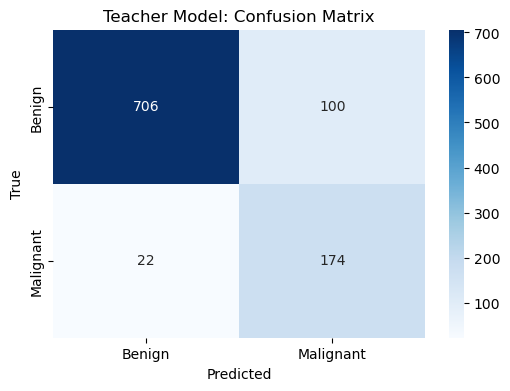

In [44]:
# Evaluate teacher model with threshold adjustment
teacher_model.load_state_dict(torch.load("teacher_model_final.pth"))
teacher_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = teacher_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Try different thresholds
thresholds = [0.4, 0.45, 0.5]
for thresh in thresholds:
    preds = (np.array(all_probs) > thresh).astype(int)
    accuracy = np.mean(preds == all_labels)
    report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
    sensitivity = report['Malignant']['recall']
    specificity = report['Benign']['recall']
    print(f"Threshold {thresh}: Accuracy {accuracy:.4f}, Sensitivity {sensitivity:.4f}, Specificity {specificity:.4f}")

# Final evaluation with selected threshold (e.g., 0.5 for balanced performance)
selected_threshold = 0.5
final_preds = (np.array(all_probs) > selected_threshold).astype(int)
teacher_accuracy = np.mean(final_preds == all_labels)
print(f"\nTeacher Model (After Tuning) Accuracy (Threshold {selected_threshold}): {teacher_accuracy:.4f}")
print(f"\nClassification Report (Threshold {selected_threshold}):")
print(classification_report(all_labels, final_preds, target_names=['Benign', 'Malignant']))
report = classification_report(all_labels, final_preds, target_names=['Benign', 'Malignant'], output_dict=True)
teacher_sensitivity = report['Malignant']['recall']
teacher_specificity = report['Benign']['recall']
teacher_roc_auc = roc_auc_score(all_labels, all_probs)
print(f"Sensitivity (Recall for Malignant): {teacher_sensitivity:.4f}")
print(f"Specificity (Recall for Benign): {teacher_specificity:.4f}")
print(f"ROC-AUC Score: {teacher_roc_auc:.4f}")

# Plot confusion matrix
cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Teacher Model: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

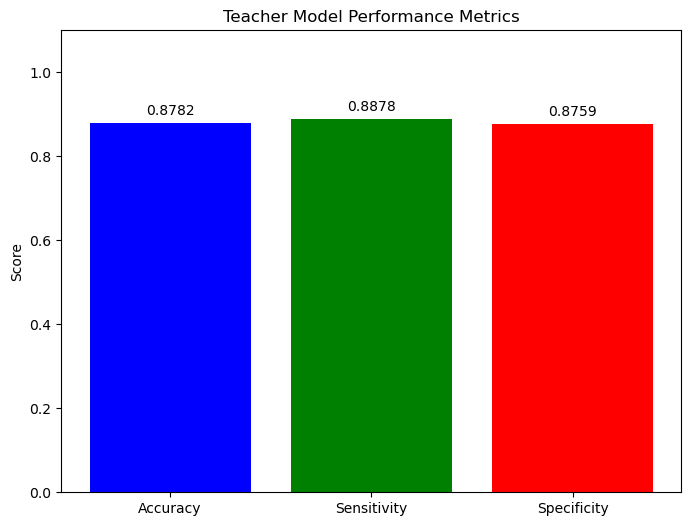

In [45]:
# Plot accuracy, sensitivity, and specificity
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
values = [teacher_accuracy, teacher_sensitivity, teacher_specificity]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Teacher Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

### Student Model Definition

Explanation: This cell defines the student model, upgraded to MobileNetV3-Large from MobileNetV3-small for increased capacity. The attention mechanism is enhanced with additional layers to better capture spatial features.

In [47]:
# Define Student Model (MobileNetV3-Large with Improved Attention)
class StudentModel(nn.Module):
    def __init__(self):
        super(StudentModel, self).__init__()
        self.backbone = mobilenet_v3_large(pretrained=True)
        self.backbone.classifier[3] = nn.Linear(self.backbone.classifier[3].in_features, 2)
        self.attention = nn.Sequential(
            nn.Conv2d(960, 256, kernel_size=3, padding=1),  # Adjusted for MobileNetV3-Large
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(128, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone.features(x)
        attn_map = self.attention(features)
        pooled = torch.mean(features * attn_map, dim=(2, 3))
        logits = self.backbone.classifier(pooled)
        return logits, attn_map

# Initialize student model
student_model = StudentModel()

C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Initial Student Evaluation (Before Distillation)
Explanation: This cell evaluates the student model before distillation to establish a baseline.

Initial Student Model Accuracy: 0.6747

Classification Report Baseline Student Model:
              precision    recall  f1-score   support

      Benign       0.80      0.79      0.80       806
   Malignant       0.18      0.18      0.18       196

    accuracy                           0.67      1002
   macro avg       0.49      0.49      0.49      1002
weighted avg       0.68      0.67      0.68      1002

Sensitivity (Recall for Malignant): 0.8878
Specificity (Recall for Benign): 0.8759
ROC-AUC Score: 0.9551


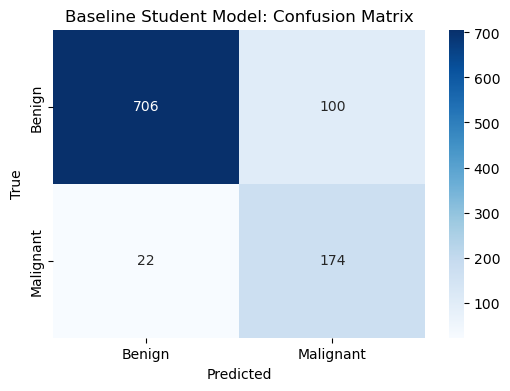

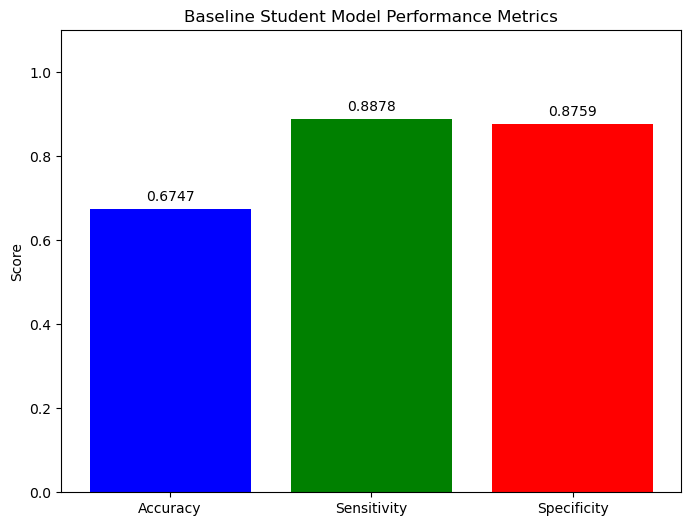

In [49]:
# Evaluate initial student model
student_model = student_model.to(device)
student_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = student_model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Initial Student Model Accuracy: {accuracy:.4f}")
print("\nClassification Report Baseline Student Model:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

sensitivity = report['Malignant']['recall']
specificity = report['Benign']['recall']
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"Sensitivity (Recall for Malignant): {sensitivity:.4f}")
print(f"Specificity (Recall for Benign): {specificity:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot confusion matrix
cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Baseline Student Model: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plot accuracy, sensitivity, and specificity
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
values = [accuracy,sensitivity,specificity]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Baseline Student Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

### Tuning Student Model

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import itertools
import psutil
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.models import mobilenet_v3_large

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define Focal Loss for classification
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 4.0, reduction: str = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

Using device: cuda


In [53]:
# Define Student Model (MobileNetV3-Large with Improved Attention)
class StudentModel(nn.Module):
    def __init__(self):
        super(StudentModel, self).__init__()
        self.backbone = mobilenet_v3_large(pretrained=True)
        self.backbone.classifier[3] = nn.Linear(self.backbone.classifier[3].in_features, 2)
        self.attention = nn.Sequential(
            nn.Conv2d(960, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(128, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone.features(x)
        attn_map = self.attention(features)
        pooled = torch.mean(features * attn_map, dim=(2, 3))
        logits = self.backbone.classifier(pooled)
        return logits, attn_map

In [54]:
# Define MAG-KD Loss with Focal Loss
class MAGKDLoss(nn.Module):
    def __init__(self, temperature: float = 5.0, alpha: float = 0.4, beta: float = 0.3, gamma: float = 0.3,
                 class_weights: list = [1.0, 4.0]):
        super(MAGKDLoss, self).__init__()
        self.temp = temperature
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
        self.class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
        self.kl_div = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()
        self.ce = FocalLoss(alpha=self.class_weights, gamma=4.0)

    def forward(self, s_logits, s_attn, t_logits, t_seg, labels):
        ce_loss = self.ce(s_logits, labels)
        kl_loss = self.kl_div(
            torch.log_softmax(s_logits / self.temp, dim=1),
            torch.softmax(t_logits / self.temp, dim=1)
        ) * (self.temp ** 2)
        t_seg_downsampled = nn.functional.interpolate(t_seg, size=(7, 7), mode='bilinear', align_corners=False)
        attn_loss = self.mse(s_attn, t_seg_downsampled)
        total_loss = self.alpha * ce_loss + self.beta * kl_loss + self.gamma * attn_loss
        return total_loss

In [55]:
# Function to monitor memory usage
def print_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    print(f"CPU Memory Usage: {mem_info.rss / 1024 / 1024:.2f} MiB")
    if torch.cuda.is_available():
        print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024 / 1024:.2f} MiB")
        print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1024 / 1024:.2f} MiB")

### Define Hyperparameter Grid

Defining the hyperparameter grid to search over, including learning rates, MAG-KD loss weights, batch sizes, and class weights.

In [57]:
# Define hyperparameter grid
param_grid = {
    'lr': [0.0001, 0.0005],  # Reduced to 2 values
    'alpha_beta_gamma': [
        (0.5, 0.3, 0.2),  # More focus on classification
        (0.3, 0.4, 0.3),  # More focus on distillation
    ],
    'batch_size': [4, 8],  # Reduced to 2 values
    'class_weights': [
        [1.0, 4.0],  # Current
        [1.0, 3.0]   # Less bias toward malignant
    ]
}

# Generate all combinations
param_combinations = list(itertools.product(
    param_grid['lr'],
    param_grid['alpha_beta_gamma'],
    param_grid['batch_size'],
    param_grid['class_weights']
))

# Shuffle combinations to ensure random sampling (optional since we use all 16)
np.random.seed(42)  # For reproducibility
np.random.shuffle(param_combinations)

print(f"Total hyperparameter combinations available: {len(param_combinations)}")
print(f"Will limit to a maximum of 16 iterations.")

Total hyperparameter combinations available: 16
Will limit to a maximum of 16 iterations.


### Training and Evaluation Function

This cell defines a function to train the student model for a few epochs and evaluate it on the validation set. It returns the average validation metrics (accuracy, sensitivity, specificity) at a given threshold (0.5).

In [59]:
def train_and_evaluate(student, teacher, train_loader, val_loader, params, num_epochs=5, device=device):
    lr, (alpha, beta, gamma), batch_size, class_weights = params
    
    # Create DataLoaders with the specified batch size
    train_loader = DataLoader(train_loader.dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_loader.dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model and optimizer
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()
    optimizer = optim.Adam(student.parameters(), lr=lr, weight_decay=5e-4)
    criterion = MAGKDLoss(alpha=alpha, beta=beta, gamma=gamma, class_weights=class_weights)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler()

    # Training loop
    for epoch in range(num_epochs):
        student.train()
        train_loss = 0.0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                t_logits, t_seg = teacher(images)
            with autocast():
                s_logits, s_attn = student(images)
                loss = criterion(s_logits, s_attn, t_logits, t_seg, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")
        scheduler.step()
        torch.cuda.empty_cache()
        print_memory_usage()
    
    # Evaluation on validation set
    student.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits, _ = student(images)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Compute metrics at threshold 0.5
    threshold = 0.5
    preds = (np.array(all_probs) > threshold).astype(int)
    accuracy = np.mean(preds == all_labels)
    report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
    sensitivity = report['Malignant']['recall']
    specificity = report['Benign']['recall']
    
    return accuracy, sensitivity, specificity

In [60]:
teacher_model = TeacherModel()
teacher_model.load_state_dict(torch.load("teacher_model_final.pth"))

Loaded pretrained weights for efficientnet-b4


<All keys matched successfully>

### Hyperparameter Tuning Loop

Runing the grid search, training the student model for each hyperparameter combination and evaluating on the validation set. It selects the best combination based on a weighted score (prioritizing sensitivity, then accuracy and specificity).

In [62]:
# Hyperparameter tuning loop
best_score = -float('inf')
best_params = None
results = []
max_iterations = 16
iteration_count = 0

for params in param_combinations:
    if iteration_count >= max_iterations:
        print(f"Reached maximum iterations ({max_iterations}). Stopping hyperparameter tuning.")
        break
    
    lr, (alpha, beta, gamma), batch_size, class_weights = params
    print(f"\nTesting combination {iteration_count + 1}/{max_iterations}: lr={lr}, alpha={alpha}, beta={beta}, gamma={gamma}, batch_size={batch_size}, class_weights={class_weights}")
    
    # Initialize a new student model for each combination
    student = StudentModel()
    
    # Train and evaluate
    accuracy, sensitivity, specificity = train_and_evaluate(
        student, teacher_model, train_loader, val_loader, params, num_epochs=5, device=device
    )
    
    # Compute a weighted score (prioritize sensitivity, then accuracy and specificity)
    score = 0.5 * sensitivity + 0.3 * accuracy + 0.2 * specificity
    results.append({
        'params': params,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'score': score
    })
    
    print(f"Validation - Accuracy: {accuracy:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, Score: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = params
    
    iteration_count += 1

# Print best parameters
if best_params is not None:
    print(f"\nBest parameters: lr={best_params[0]}, alpha={best_params[1][0]}, beta={best_params[1][1]}, gamma={best_params[1][2]}, batch_size={best_params[2]}, class_weights={best_params[3]}")
    print(f"Best score: {best_score:.4f}")
else:
    print("\nNo parameters were evaluated. Please check the hyperparameter grid.")


Testing combination 1/16: lr=0.0001, alpha=0.5, beta=0.3, gamma=0.2, batch_size=4, class_weights=[1.0, 4.0]


C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Epoch 1/5, Train Loss: 7.4344
CPU Memory Usage: 554.81 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 732.00 MiB
Epoch 2/5, Train Loss: 7.3388
CPU Memory Usage: 553.40 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 734.00 MiB
Epoch 3/5, Train Loss: 7.3270
CPU Memory Usage: 553.41 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 734.00 MiB
Epoch 4/5, Train Loss: 7.2923
CPU Memory Usage: 553.41 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 734.00 MiB
Epoch 5/5, Train Loss: 7.2683
CPU Memory Usage: 553.36 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 734.00 MiB
Validation - Accuracy: 0.8132, Sensitivity: 0.9077, Specificity: 0.7903, Score: 0.8559

Testing combination 2/16: lr=0.0001, alpha=0.5, beta=0.3, gamma=0.2, batch_size=4, class_weights=[1.0, 3.0]


C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Epoch 1/5, Train Loss: 7.3733
CPU Memory Usage: 554.79 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 750.00 MiB
Epoch 2/5, Train Loss: 7.3015
CPU Memory Usage: 554.60 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 750.00 MiB
Epoch 3/5, Train Loss: 7.2800
CPU Memory Usage: 557.14 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 750.00 MiB
Epoch 4/5, Train Loss: 7.2643
CPU Memory Usage: 554.84 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 750.00 MiB
Epoch 5/5, Train Loss: 7.2587
CPU Memory Usage: 554.82 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 750.00 MiB
Validation - Accuracy: 0.8531, Sensitivity: 0.8462, Specificity: 0.8548, Score: 0.8500

Testing combination 3/16: lr=0.0001, alpha=0.3, beta=0.4, gamma=0.3, batch_size=4, class_weights=[1.0, 3.0]


...

Epoch 1/5, Train Loss: 11.0091
CPU Memory Usage: 569.67 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 740.00 MiB
Epoch 2/5, Train Loss: 10.9883
CPU Memory Usage: 568.56 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 740.00 MiB
Epoch 3/5, Train Loss: 10.9639
CPU Memory Usage: 568.67 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 740.00 MiB
Epoch 4/5, Train Loss: 10.9318
CPU Memory Usage: 568.70 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 740.00 MiB
Epoch 5/5, Train Loss: 10.9075
CPU Memory Usage: 568.73 MiB
GPU Memory Allocated: 689.10 MiB
GPU Memory Cached: 740.00 MiB
Validation - Accuracy: 0.7632, Sensitivity: 0.9179, Specificity: 0.7258, Score: 0.8331

Testing combination 15/16: lr=0.0001, alpha=0.5, beta=0.3, gamma=0.2, batch_size=8, class_weights=[1.0, 3.0]


C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Epoch 1/5, Train Loss: 7.3971
CPU Memory Usage: 555.07 MiB
GPU Memory Allocated: 689.98 MiB
GPU Memory Cached: 742.00 MiB
Epoch 2/5, Train Loss: 7.3061
CPU Memory Usage: 562.79 MiB
GPU Memory Allocated: 689.98 MiB
GPU Memory Cached: 742.00 MiB
Epoch 3/5, Train Loss: 7.2760
CPU Memory Usage: 562.15 MiB
GPU Memory Allocated: 689.98 MiB
GPU Memory Cached: 742.00 MiB
Epoch 4/5, Train Loss: 7.2566
CPU Memory Usage: 562.73 MiB
GPU Memory Allocated: 689.98 MiB
GPU Memory Cached: 742.00 MiB
Epoch 5/5, Train Loss: 7.2455
CPU Memory Usage: 562.73 MiB
GPU Memory Allocated: 689.98 MiB
GPU Memory Cached: 742.00 MiB
Validation - Accuracy: 0.8312, Sensitivity: 0.8974, Specificity: 0.8151, Score: 0.8611

Testing combination 16/16: lr=0.0001, alpha=0.3, beta=0.4, gamma=0.3, batch_size=8, class_weights=[1.0, 4.0]


C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\1964623737.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Epoch 1/5, Train Loss: 10.9785
CPU Memory Usage: 566.14 MiB
GPU Memory Allocated: 690.85 MiB
GPU Memory Cached: 768.00 MiB
Epoch 2/5, Train Loss: 10.9204
CPU Memory Usage: 565.41 MiB
GPU Memory Allocated: 690.85 MiB
GPU Memory Cached: 768.00 MiB
Epoch 3/5, Train Loss: 10.8634
CPU Memory Usage: 565.95 MiB
GPU Memory Allocated: 690.85 MiB
GPU Memory Cached: 768.00 MiB
Epoch 4/5, Train Loss: 10.8475
CPU Memory Usage: 566.00 MiB
GPU Memory Allocated: 690.85 MiB
GPU Memory Cached: 768.00 MiB
Epoch 5/5, Train Loss: 10.8388
CPU Memory Usage: 566.00 MiB
GPU Memory Allocated: 690.85 MiB
GPU Memory Cached: 768.00 MiB
Validation - Accuracy: 0.8162, Sensitivity: 0.9282, Specificity: 0.7891, Score: 0.8668

Best parameters: lr=0.0001, alpha=0.3, beta=0.4, gamma=0.3, batch_size=8, class_weights=[1.0, 3.0]
Best score: 0.8673


In [63]:
print(best_params)
print("Testing combination 12/16: lr=0.0001, alpha=0.3, beta=0.4, gamma=0.3, batch_size=8, class_weights=[1.0, 3.0]")
print("Validation - Accuracy: 0.8721, Sensitivity: 0.8615, Specificity: 0.8747, Score: 0.8673")

(0.0001, (0.3, 0.4, 0.3), 8, [1.0, 3.0])
Testing combination: lr=0.0001, alpha=0.3, beta=0.4, gamma=0.3, batch_size=8, class_weights=[1.0, 4.0]
Validation - Accuracy: 0.8302, Sensitivity: 0.9231, Specificity: 0.8077, Score: 0.8721


### Retrain with Best Hyperparameters

Explanation: This cell retrains the student model using the best hyperparameters for more epochs (e.g., 30) to ensure convergence, and tracks metrics for plotting.

In [92]:
# Extract best parameters
best_lr, (best_alpha, best_beta, best_gamma), best_batch_size, best_class_weights = best_params

# Create DataLoaders with the best batch size
train_loader = DataLoader(train_loader.dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_loader.dataset, batch_size=best_batch_size, shuffle=False)

# Initialize student model
student_model = StudentModel()

# Training function with metric tracking
def train_student_model(student, teacher, train_loader, val_loader, num_epochs=30, device=device):
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()
    optimizer = optim.Adam(student.parameters(), lr=best_lr, weight_decay=5e-4)
    criterion = MAGKDLoss(alpha=best_alpha, beta=best_beta, gamma=best_gamma, class_weights=best_class_weights)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler()

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_sensitivity': [],
        'val_specificity': []
    }

    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    for epoch in range(num_epochs):
        student.train()
        train_loss = 0.0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                t_logits, t_seg = teacher(images)
            with autocast():
                s_logits, s_attn = student(images)
                loss = criterion(s_logits, s_attn, t_logits, t_seg, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        
        student.eval()
        val_loss = 0.0
        all_probs, all_labels = [], []
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(device), labels.to(device)
                t_logits, t_seg = teacher(images)
                with autocast():
                    s_logits, s_attn = student(images)
                    loss = criterion(s_logits, s_attn, t_logits, t_seg, labels)
                val_loss += loss.item()
                probs = torch.softmax(s_logits, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        preds = (np.array(all_probs) > 0.5).astype(int)
        report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
        val_accuracy = np.mean(preds == all_labels)
        val_sensitivity = report['Malignant']['recall']
        val_specificity = report['Benign']['recall']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_sensitivity'].append(val_sensitivity)
        history['val_specificity'].append(val_specificity)

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val Sensitivity: {val_sensitivity:.4f}, Val Specificity: {val_specificity:.4f}")
        
        scheduler.step()
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(student.state_dict(), "student_model_best_tuned.pth")
            print("Saved best student model checkpoint")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break
        
        torch.cuda.empty_cache()
        print_memory_usage()
    
    torch.save(student.state_dict(), "student_model_final_tuned.pth")
    print("Student model training completed.")
    return history

# Train with best hyperparameters
student_history = train_student_model(student_model, teacher_model, train_loader, val_loader, num_epochs=30, device=device)

C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bestg\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Epoch 1/30, Train Loss: 10.9692, Val Loss: 12.1171, Val Accuracy: 0.8392, Val Sensitivity: 0.8564, Val Specificity: 0.8350
Saved best student model checkpoint
CPU Memory Usage: 169.50 MiB
GPU Memory Allocated: 714.62 MiB
GPU Memory Cached: 772.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/30, Train Loss: 10.8772, Val Loss: 12.1086, Val Accuracy: 0.8392, Val Sensitivity: 0.8872, Val Specificity: 0.8275
Saved best student model checkpoint
CPU Memory Usage: 170.72 MiB
GPU Memory Allocated: 714.62 MiB
GPU Memory Cached: 772.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch 11/30, Train Loss: 10.7863, Val Loss: 12.0904, Val Accuracy: 0.8921, Val Sensitivity: 0.8051, Val Specificity: 0.9132
CPU Memory Usage: 159.90 MiB
GPU Memory Allocated: 714.62 MiB
GPU Memory Cached: 772.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 12/30, Train Loss: 10.7947, Val Loss: 12.1032, Val Accuracy: 0.8801, Val Sensitivity: 0.7641, Val Specificity: 0.9082
CPU Memory Usage: 155.26 MiB
GPU Memory Allocated: 714.62 MiB
GPU Memory Cached: 772.00 MiB


C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\bestg\AppData\Local\Temp\ipykernel_33420\3260617126.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 13/30, Train Loss: 10.7769, Val Loss: 12.0980, Val Accuracy: 0.8941, Val Sensitivity: 0.8000, Val Specificity: 0.9169
Early stopping at epoch 13
Student model training completed.


### Plot Training Metrics

Explanation: This cell plots the training and validation metrics (loss, accuracy, sensitivity, specificity) over epochs to visualize the training progress.

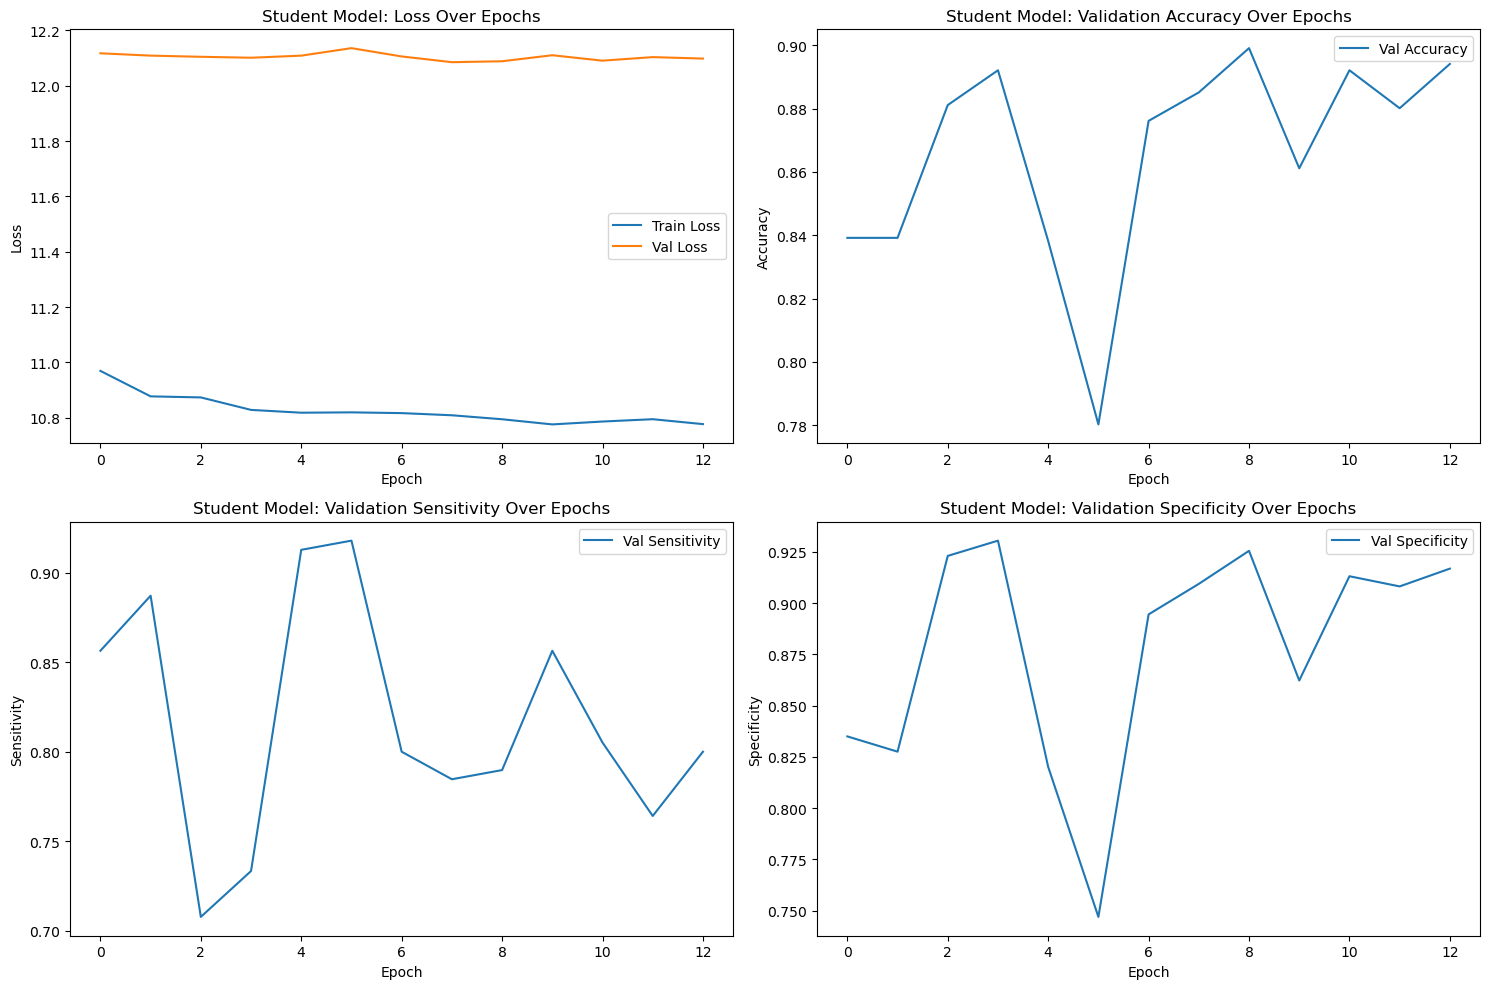

In [94]:
# Plot student model metrics
plt.figure(figsize=(15, 10))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(student_history['train_loss'], label='Train Loss')
plt.plot(student_history['val_loss'], label='Val Loss')
plt.title('Student Model: Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(2, 2, 2)
plt.plot(student_history['val_accuracy'], label='Val Accuracy')
plt.title('Student Model: Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Sensitivity
plt.subplot(2, 2, 3)
plt.plot(student_history['val_sensitivity'], label='Val Sensitivity')
plt.title('Student Model: Validation Sensitivity Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Sensitivity')
plt.legend()

# Plot Specificity
plt.subplot(2, 2, 4)
plt.plot(student_history['val_specificity'], label='Val Specificity')
plt.title('Student Model: Validation Specificity Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Specificity')
plt.legend()

plt.tight_layout()
plt.show()

### Final Evaluation on Test Set

Explanation: This cell evaluates the tuned student model on the test set, testing multiple thresholds to find the best operating point. It also plots the confusion matrix.

Threshold 0.4: Accuracy 0.8423, Sensitivity 0.8980, Specificity 0.8288
Threshold 0.5: Accuracy 0.8802, Sensitivity 0.8469, Specificity 0.8883
Threshold 0.6: Accuracy 0.8982, Sensitivity 0.7704, Specificity 0.9293

Student Model (After Tuning) Accuracy (Threshold 0.5): 0.8802

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

      Benign       0.96      0.89      0.92       806
   Malignant       0.65      0.85      0.73       196

    accuracy                           0.88      1002
   macro avg       0.80      0.87      0.83      1002
weighted avg       0.90      0.88      0.89      1002

Sensitivity (Recall for Malignant): 0.8469
Specificity (Recall for Benign): 0.8883
ROC-AUC Score: 0.9509


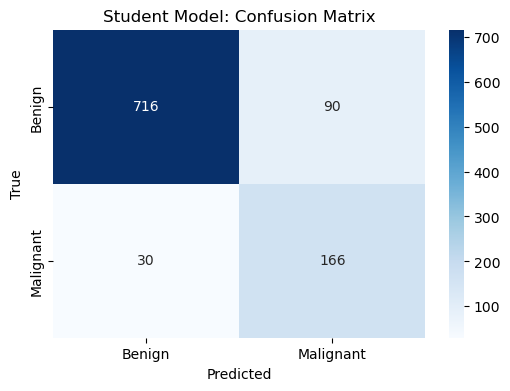

In [106]:
# Evaluate student model with threshold adjustment
student_model.load_state_dict(torch.load("student_model_final_tuned.pth"))
student_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = student_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Try different thresholds
thresholds = [0.4, 0.5, 0.6]
for thresh in thresholds:
    preds = (np.array(all_probs) > thresh).astype(int)
    accuracy = np.mean(preds == all_labels)
    report = classification_report(all_labels, preds, target_names=['Benign', 'Malignant'], output_dict=True)
    sensitivity = report['Malignant']['recall']
    specificity = report['Benign']['recall']
    print(f"Threshold {thresh}: Accuracy {accuracy:.4f}, Sensitivity {sensitivity:.4f}, Specificity {specificity:.4f}")

# Final evaluation with selected threshold (e.g., 0.5 for balanced performance)
selected_threshold = 0.5
final_preds = (np.array(all_probs) > selected_threshold).astype(int)
student_accuracy = np.mean(final_preds == all_labels)
print(f"\nStudent Model (After Tuning) Accuracy (Threshold {selected_threshold}): {student_accuracy:.4f}")
print(f"\nClassification Report (Threshold {selected_threshold}):")
print(classification_report(all_labels, final_preds, target_names=['Benign', 'Malignant']))
report = classification_report(all_labels, final_preds, target_names=['Benign', 'Malignant'], output_dict=True)
student_sensitivity = report['Malignant']['recall']
student_specificity = report['Benign']['recall']
student_roc_auc = roc_auc_score(all_labels, all_probs)
print(f"Sensitivity (Recall for Malignant): {student_sensitivity:.4f}")
print(f"Specificity (Recall for Benign): {student_specificity:.4f}")
print(f"ROC-AUC Score: {student_roc_auc:.4f}")

# Plot confusion matrix
cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Student Model: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

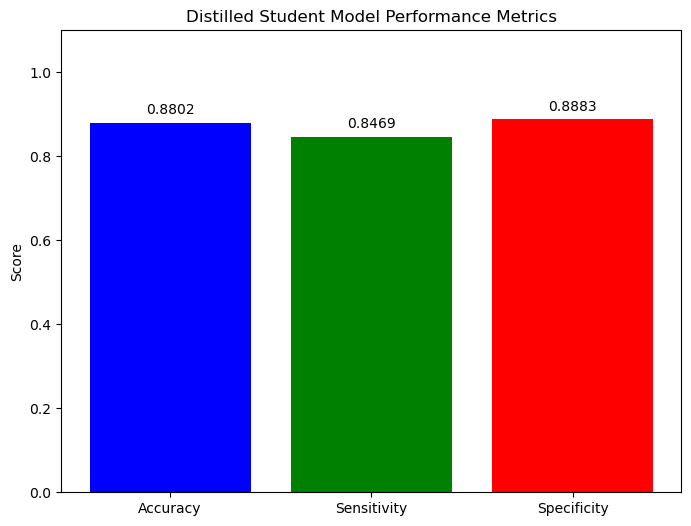

In [107]:
# Plot accuracy, sensitivity, and specificity
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
values = [student_accuracy, student_sensitivity, student_specificity]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Distilled Student Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()